In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../Data/interim/cleaned_rainfall.csv")

<Axes: xlabel='ANNUAL', ylabel='Count'>

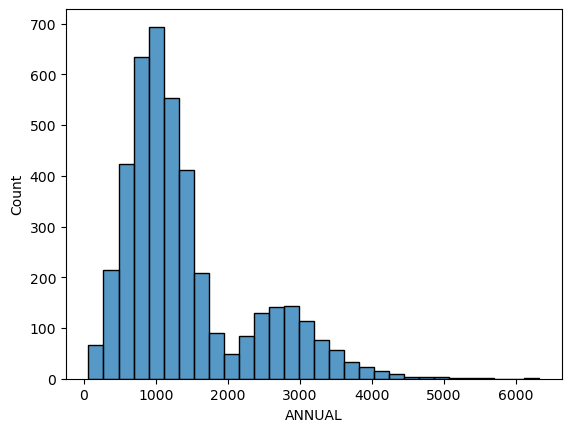

In [3]:
sns.histplot(df["ANNUAL"], bins=30) 

#this will create a histrogram for ANNUAL column of 30 bins 

### Observation

- The distribution of annual rainfall is positively (right) skewed.
- Most observations lie between approximately 600 mm and 1500 mm.
- A smaller group of observations lies between 2500 mm and 3500 mm, suggesting regional climatic differences.
- A few very high rainfall values (>5000 mm) are present. These will be investigated further during outlier analysis to determine whether they are genuine observations or anomalies.

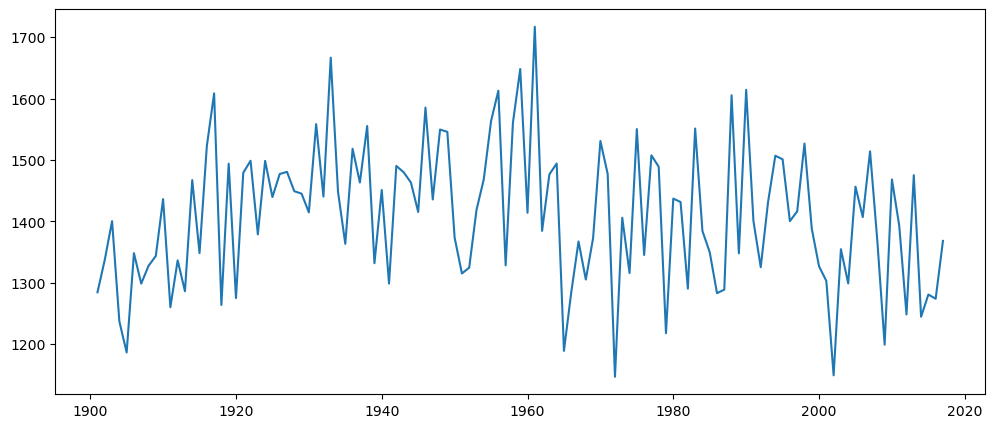

In [4]:
yearly = df.groupby("YEAR")["ANNUAL"].mean()

plt.figure(figsize=(12,5))
plt.plot(yearly)
plt.show()

#so here we have plotted a line graph for ANNUAL rainfall YEAR wise 

## Observation

- The average annual rainfall varies considerably from year to year.
- No significant long-term increasing or decreasing trend is observed during the period 1901–2017.
- Several years exhibit exceptionally high rainfall, while others show relatively low rainfall.
- The fluctuations indicate natural variability in the Indian monsoon system.
- No clear periodic or cyclic rainfall pattern is evident from the time series.

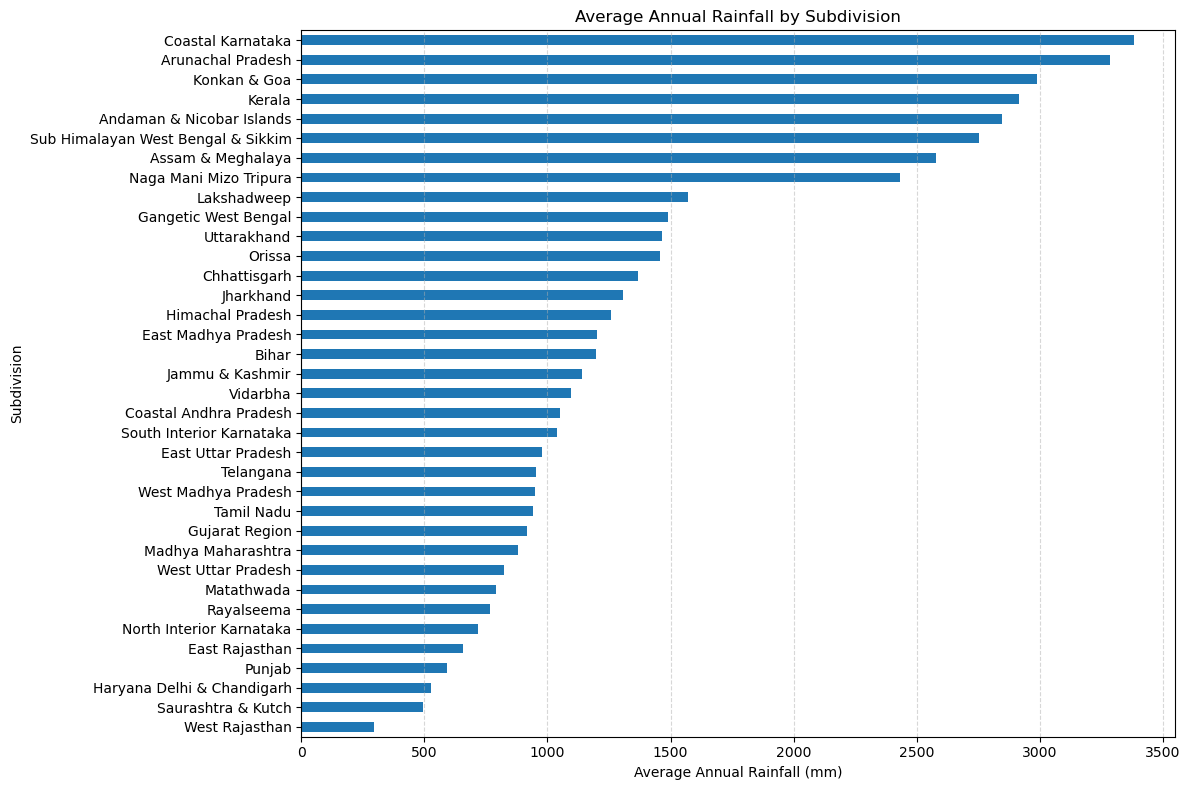

In [5]:
top_regions = df.groupby("SUBDIVISION")["ANNUAL"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,8))

top_regions.plot(kind='barh')

plt.title("Average Annual Rainfall by Subdivision")
plt.xlabel("Average Annual Rainfall (mm)")
plt.ylabel("Subdivision")

plt.gca().invert_yaxis()   # Highest rainfall at the top

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

### Observation

- The average annual rainfall varies significantly across India's meteorological subdivisions.
- A few subdivisions receive exceptionally high rainfall (>3000 mm), while some receive less than 500 mm annually.
- This spatial variability reflects the influence of regional climate, topography, and monsoon dynamics.
- Such differences are important because rainfall is a major factor influencing groundwater recharge.

<Axes: >

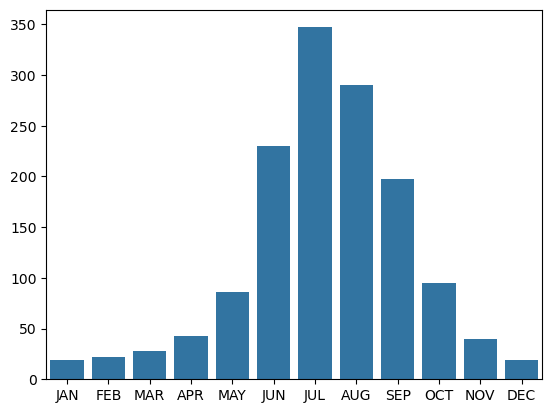

In [6]:
months = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']

avg_monthly_rain = df[months].mean()

sns.barplot(avg_monthly_rain)
#so this will give a bar-chart for average monthly rainfall 

<Axes: >

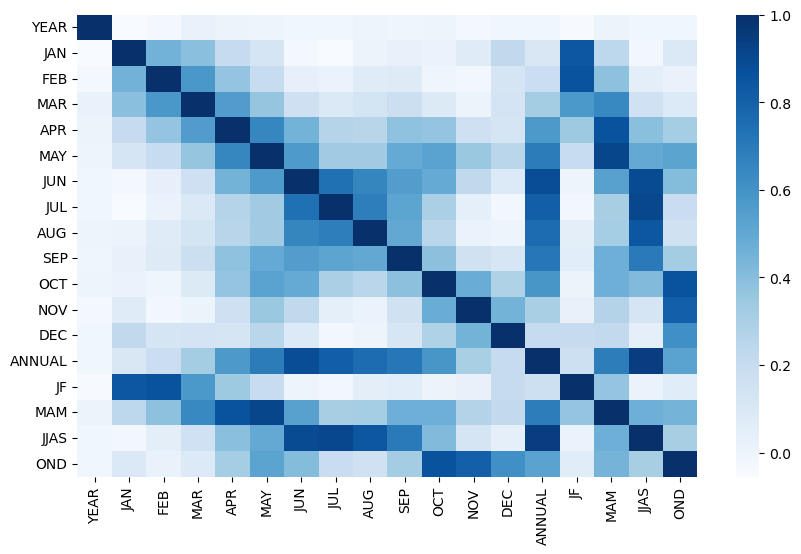

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="Blues")

#so this will give a correlation heatmap with all the numeric-valued columns i.e. it compares all the numeric-valued columns nd shows how much it affects each other and which months influence annual rainfall most?

### Observation

- The correlation heatmap illustrates the linear relationship among all numerical variables in the rainfall dataset.
- The `ANNUAL` rainfall variable shows a strong positive correlation with the monsoon months (`JUN`, `JUL`, `AUG`, and `SEP`) as well as the `JJAS` seasonal rainfall, indicating that these months contribute significantly to the total annual rainfall.
- The seasonal rainfall variables (`JF`, `MAM`, `JJAS`, and `OND`) exhibit high correlations with their corresponding monthly rainfall values, as expected since they are derived from those months.
- Rainfall during adjacent months (e.g., `JUN`–`JUL`, `JUL`–`AUG`, and `AUG`–`SEP`) also shows relatively strong positive correlations, suggesting similar monsoon rainfall patterns.
- The `YEAR` variable has a very weak correlation with most rainfall variables, indicating that no strong linear relationship exists between time and rainfall over the study period (1901–2017).
- Overall, the heatmap suggests that the Southwest Monsoon season (`JJAS`) is the primary contributor to India's annual rainfall.

Text(0, 0.5, 'Rainfall (mm)')

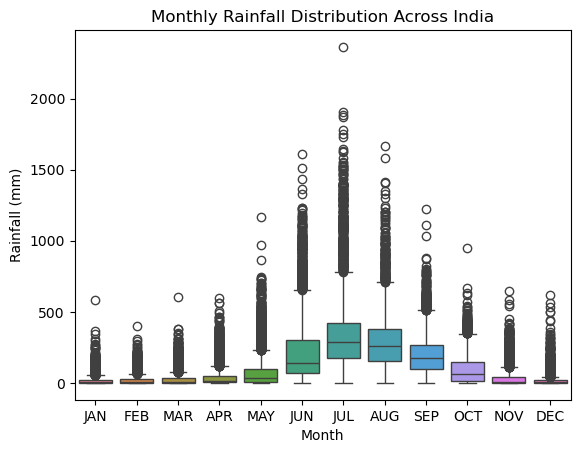

In [8]:
sns.boxplot(data=df[months])
plt.title("Monthly Rainfall Distribution Across India")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")

#NOTE:- Long whiskers indicate a wider range of normal rainfall values.

### Observation

- The boxplots illustrate the monthly distribution of rainfall across all years and meteorological subdivisions.
- Rainfall is lowest during the winter months (January–March and December), with low median values and relatively small variability.
- Rainfall increases from April onwards and reaches its peak during the Southwest Monsoon season (June–September), particularly in July.
- July exhibits the highest median rainfall and the greatest variability, indicating that it is generally the wettest month across India.
- The monsoon months show wider interquartile ranges (IQRs), suggesting greater variation in rainfall across different regions and years.
- Numerous outliers are observed, especially during the monsoon season. These likely represent regions experiencing exceptionally high rainfall and should not be treated as errors without further investigation.
- Overall, the boxplots clearly reflect the seasonal rainfall pattern associated with the Indian monsoon.

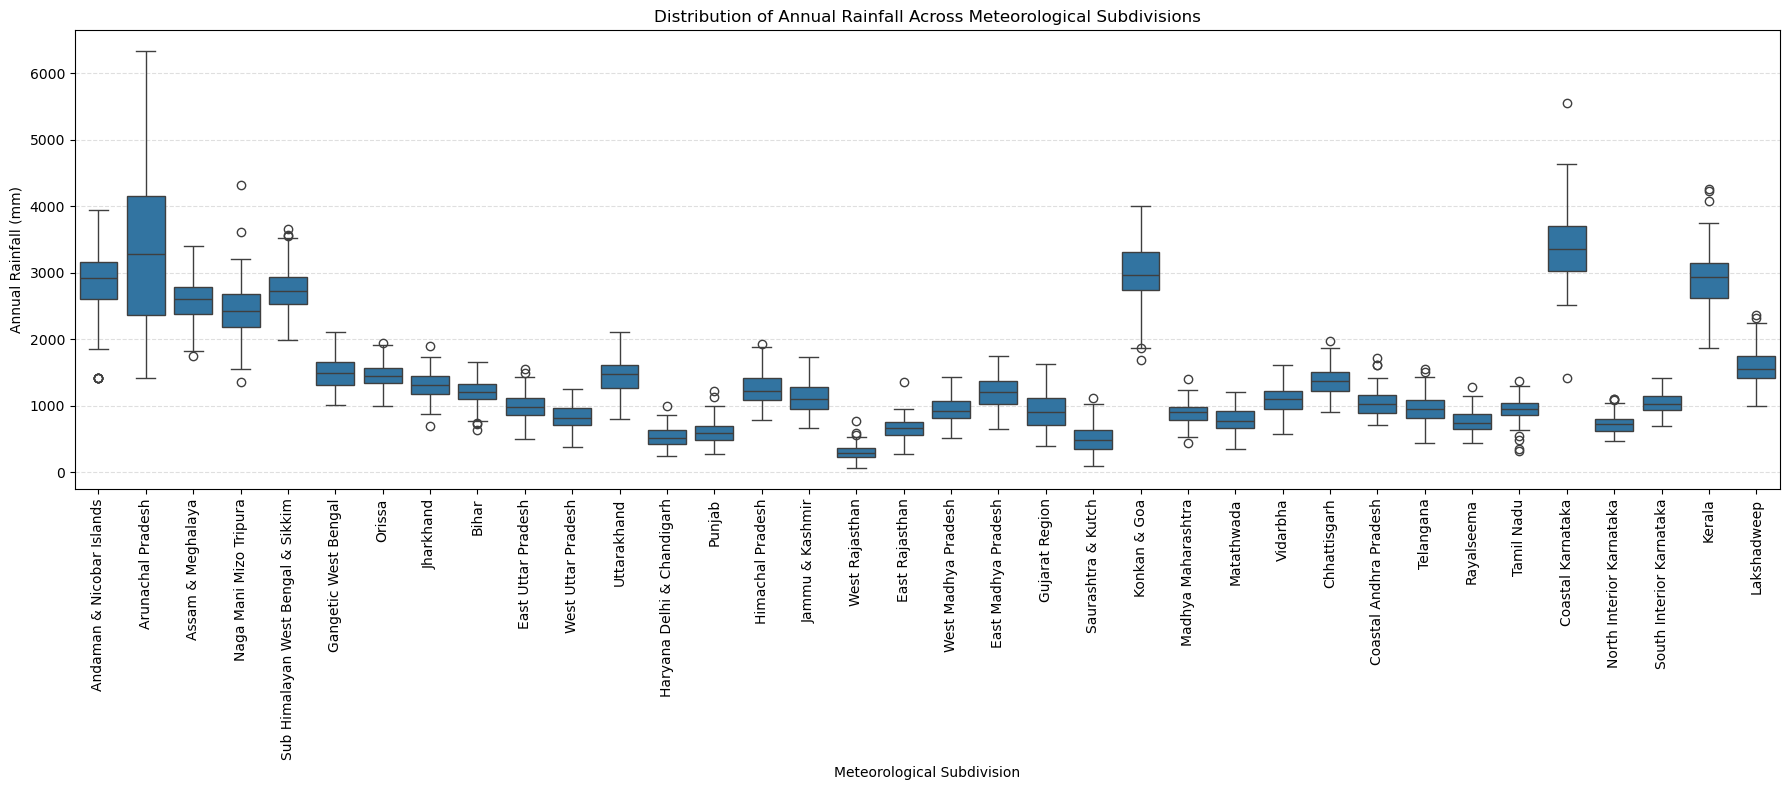

In [9]:
plt.figure(figsize=(18,8))

sns.boxplot(x="SUBDIVISION", y="ANNUAL", data=df)

plt.xticks(rotation=90)

plt.title("Distribution of Annual Rainfall Across Meteorological Subdivisions")
plt.xlabel("Meteorological Subdivision")
plt.ylabel("Annual Rainfall (mm)")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

#this will give us the boxplot for rainfall by subdivisions

### Observation

- The boxplot compares the distribution of annual rainfall across India's meteorological subdivisions.
- The median annual rainfall varies considerably among subdivisions, indicating significant spatial variation in rainfall.
- Some subdivisions exhibit a larger interquartile range (IQR), suggesting higher year-to-year variability in annual rainfall.
- Several subdivisions contain numerous high-value outliers, representing years with exceptionally high rainfall.
- Differences in rainfall distribution across subdivisions highlight the influence of regional geography, topography, and monsoon dynamics.
- These spatial variations are important for groundwater studies because regions with higher and more consistent rainfall generally have greater potential for groundwater recharge.

Outliers are observed both above and below the whiskers. Upper outliers represent years with exceptionally high rainfall, while lower outliers represent unusually dry years. Since these values may correspond to genuine climatic events such as heavy monsoon seasons or droughts, they are retained for further analysis rather than being treated as data errors.